In [10]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [39]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

### 1.a Execution des expériences

In [69]:
# Groupes de features analysés
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u',
                      #'sp', 
                      'jc', 'aa', 'cn',
                      'dc_v']
features_commu_inferee = ['louvain_v', 'same_louvain', 'infomap_u', 'infomap_v', 'same_infomap', 'sbm_u', 'sbm_v', 'same_sbm']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm']
#features_embeddings = ['n2v_p2_q0.5_cosine', 'n2v_p2_q0.5_dist', 'n2v_p1_q1_cosine', 'n2v_p1_q1_dist']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]
features_ground_truth = ['block_reel_u', 'block_reel_v','same_block_reel', "dist_reelle", "proba_lien_reelle"]
features_ground_truth_same_group_only = ['same_block_reel']
features_ground_truth_proba_only = ['proba_lien_reelle']
#features_gt_shuffled = ['group_u_shuffled', 'group_v_shuffled', 'same_group_shuffled']

experiments = {
    "Ground_Truth_Only_SG" : features_ground_truth_same_group_only,
    "Ground_Truth_Only": features_ground_truth,
    "Ground_truth_Only_proba" : features_ground_truth_proba_only,
    #"Ground_Truth_Shuffled": features_gt_shuffled,
    "Structure_Only": features_structure,
    "Structure_with_GT": features_structure + features_ground_truth,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    "Inferred_Commu_sg_only": features_commu_inferee_same_group_only,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    "Full_with_Embeddings": features_structure + features_commu_inferee + features_embeddings
}

# --- PRÉPARATION DE L'ÉVALUATION (FIXE) ---
G_name_eval = "artificial_graph_sbm_1_00_pos_0_00"
G_obj_eval = load_json(f"graph_library/{G_name_eval}.json")
G_train_eval, _, _, _, _ = gp.load_all_data_for_graph(G_name_eval)
#eval_dataset = gp.prepare_balanced_data(G_obj_eval, G_train_eval, negative_ratio=50.0, seed=42)
eval_dataset = gp.enrich_dataset_with_ground_truth(eval_dataset, G_obj_eval, p_intra=0.6, q_inter=0.1)

print(f"EvalDataset : {eval_dataset.columns}")

all_results = []

for i in [1.00]:
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    _, dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
    G_obj = load_json(f"graph_library/{G_name}.json")

    # 2. Injection de la vérité terrain (même renommage que pour eval_dataset)
    dataset = gp.enrich_dataset_with_ground_truth(dataset, G_obj, p_intra=0.6, q_inter=0.1)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f" Running: {exp_name} for SBM={i}")
        stats_df, model, X_test, _, y_test, _, probs, preds = gp.train_and_eval_xgboost(dataset, features=feat_list, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        if exp_name == "Ground_Truth_Only":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = eval_dataset[feat_list] 
        stats_eval_df = gp.evaluate_model_performance(model, X_eval_fixed, eval_dataset["target"])
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["AP"].iloc[0],
            "AUC-ROC_train": stats_df["AUC-ROC"].iloc[0],
            "AP_eval_fixe": stats_eval_df["AP"].iloc[0],
            "AUC-ROC_eval_fixe": stats_eval_df["AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_vs_gt.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Graphe chargé : 1000 nœuds et 3500 liens.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_1_00_pos_0_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 38500 lignes, 33 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Calcul des distances réel

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


 Running: Ground_Truth_Only_SG for SBM=1.0

 RÉSULTATS
[{'F1-Score': 0.9847009735744089, 'AUC-ROC': 0.9909503342884431, 'AP': 0.971196324566798, 'AUC-PR': 0.9854820991450517}]
Top 5 Feature Importance pour Ground_Truth_Only_SG :
same_block_reel   1.000

 RÉSULTATS D'ÉVALUATION
------------------------------
F1-Score   : 0.932
AUC-ROC    : 0.9836
AP         : 0.8705
AUC-PR     : 0.9337
------------------------------
 Running: Ground_Truth_Only for SBM=1.0

 RÉSULTATS
[{'F1-Score': 0.9847009735744089, 'AUC-ROC': 0.9967319325055715, 'AP': 0.9710553564479355, 'AUC-PR': 0.9710016718802553}]
Top 5 Feature Importance pour Ground_Truth_Only :
same_block_reel     0.996
block_reel_u        0.001
block_reel_v        0.001
dist_reelle         0.001
proba_lien_reelle   0.000

 RÉSULTATS D'ÉVALUATION
------------------------------
F1-Score   : 0.9327
AUC-ROC    : 0.998
AP         : 0.9024
AUC-PR     : 0.9024
------------------------------
 Running: Ground_truth_Only_proba for SBM=1.0

 RÉSULTATS
[{'

### 1.b Analyse détaillée des faux positifs, vrais pos, etc ...

In [72]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

Taux de liens réels (p) au sein d'un bloc :
Sans voisins communs : 0.9848
Avec voisins communs : 0.9791
--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
Taux réel quand CN = 0 : 0.9420
Taux réel quand CN > 0 : 0.8966
--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
    mean  count
sp             
1  1.000   2888
2  0.875    570
3  0.857      7

Taux réel quand SP = 0 (aucun chemin) : nan
Taux réel quand SP > 0 (chemin existe) : 0.8974

============= DEEP DIVE PERFORMANCE : GT Only ==============
Nombre total de paires : 7700
------------------------------------------------------------
VRAIS POSITIFS (TP) : 708
  ├─ Intra-bloc : 708 | Inter-bloc : 0
  └─ Dont déjà connus (SP=1) : 603 (85.2%)
  └─ Trouvés par intelligence (SP!=1) : 105
------------------------------------------------------------
FAUX POSITIFS (FP) : 10
  ├─ Intra-bloc : 10 (Confusion même bloc)
  ├─ Inter-bloc : 0 (Erreur sur

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_11338/2678378530.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()


### 1.c plots des AP curves

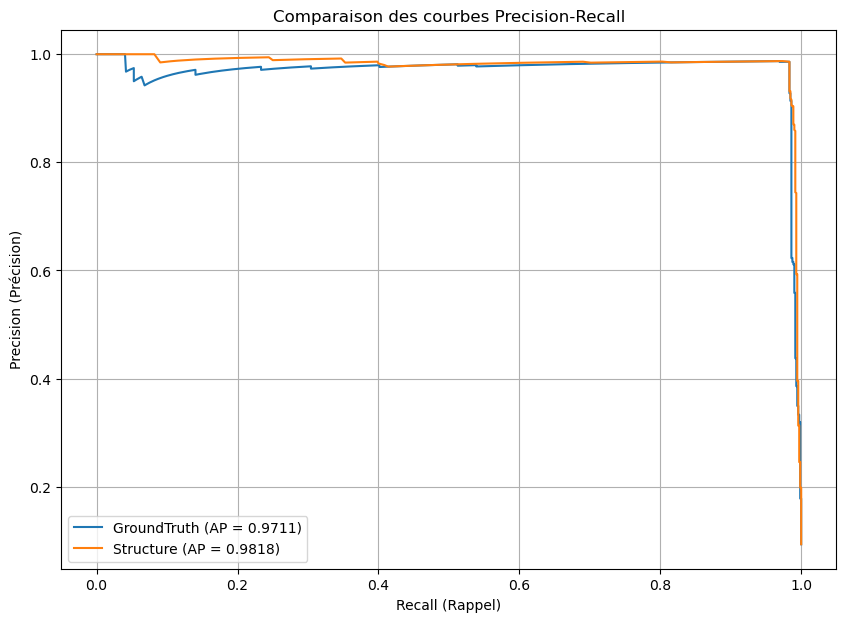

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

### 1.d Analyse de variance de probas prédites

In [76]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)


=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===
                          Type       Modèle  Variance  Valeurs Uniques  Moyenne
  Intra-Bloc (Même communauté) Ground Truth     0.001              567    0.978
  Intra-Bloc (Même communauté)    Structure     0.001               99    0.976
Inter-Bloc (Communautés diff.) Ground Truth     0.000             5568    0.003
Inter-Bloc (Communautés diff.)    Structure     0.000             4483    0.003


Graphique sauvegardé ici : outputs/plots/artificial_graphs_comparaison_F1-Score_per_SBM_ratio.png


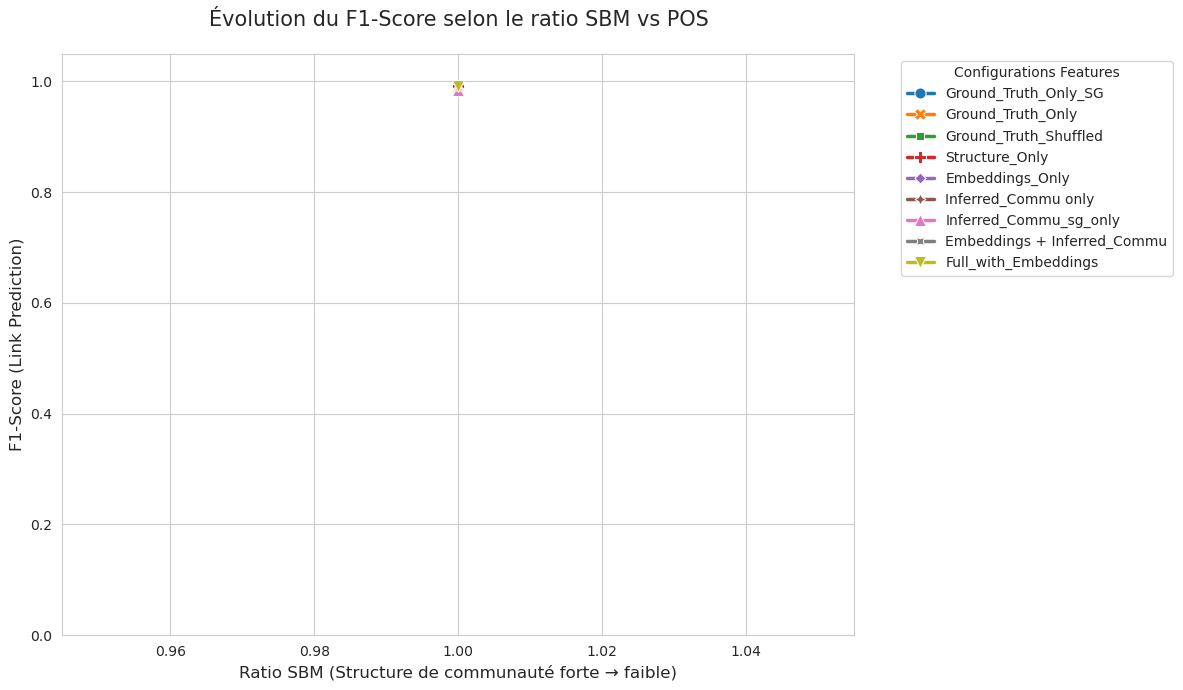

In [28]:
def plot_f1_comparison(df_results, metric="F1-Score"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 1.05) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"artificial_graphs_comparaison_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

plot_f1_comparison(df_compare)

### 1.2 Exploration visuelle des positions et catégories

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


NameError: name 'PROJECT_ROOT' is not defined

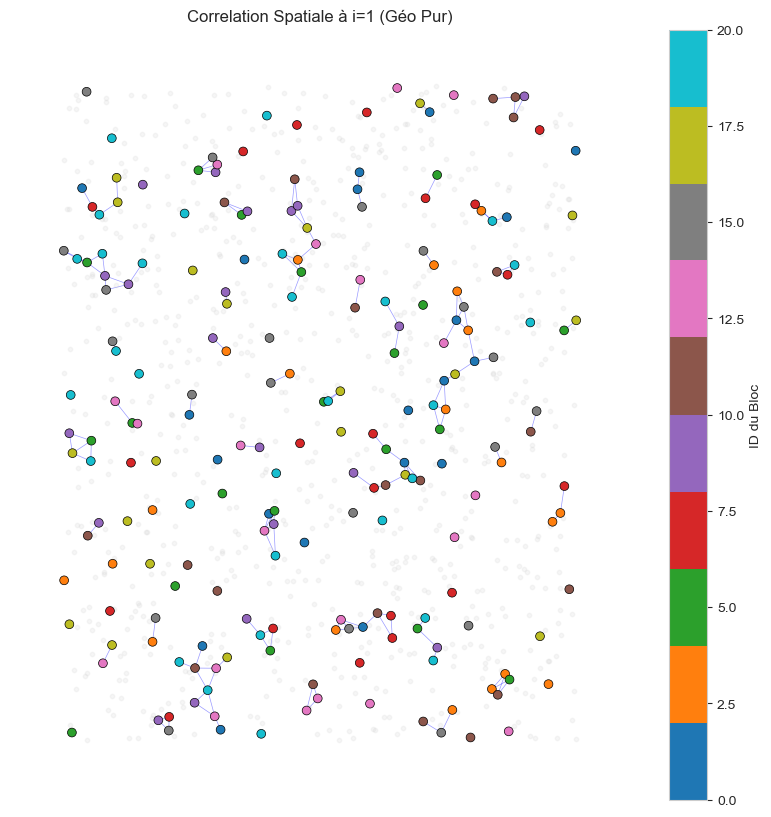

In [81]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.3 Evaluation perfs sur echantillon plus large

In [79]:
def generate_extended_eval_data(G, initial_pairs_df, expansion_factor=50, concat = True):
    nodes_list = list(G.nodes())
    num_initial = len(initial_pairs_df)
    target_extra = num_initial * expansion_factor

    existing_pairs = set()
    for u, v in zip(initial_pairs_df['u'], initial_pairs_df['v']):
        existing_pairs.add(tuple(sorted((u, v))))

    extra_pairs_list = []
    current_extra_set = set() 
    
    while len(extra_pairs_list) < target_extra:
        batch_size = min(target_extra - len(extra_pairs_list), 50000)
        random_u = np.random.choice(nodes_list, size=batch_size)
        random_v = np.random.choice(nodes_list, size=batch_size)
        
        for u, v in zip(random_u, random_v):
            if u == v:
                continue
            
            pair = tuple(sorted((u, v)))
            
            if pair not in existing_pairs and pair not in current_extra_set:
                current_extra_set.add(pair)
                extra_pairs_list.append({'u': u, 'v': v, 'target': 0})
            
            if len(extra_pairs_list) >= target_extra:
                break

    extra_df = pd.DataFrame(extra_pairs_list)
    
    if concat: 
        full_df = pd.concat([initial_pairs_df, extra_df], ignore_index=True)
    else:
        full_df = extra_df

    full_df = add_ground_truth_groups(full_df, G)
    
    return full_df

def run_scaling_evaluation(G, base_dataset, experiments_dict, eval_data, factors=[10, 20, 30, 40, 50]):
    all_results = []
    
    for factor in factors:
        print(f"\n" + "="*50)
        print(f" TEST AVEC EXPANSION FACTOR : {factor}")
        print("="*50)
        
        # 1. Génération du dataset d'entraînement étendu
        extended_train_data = generate_extended_eval_data(G, base_dataset, expansion_factor=factor, concat=True)
        
        for exp_name, feat_list in experiments_dict.items():
            print(f"\n🔹 Expérience : {exp_name}")
            
            # 3. Entraînement et Test classique (sur le set étendu)
            stats_train, model, X_test_base, _, y_test_base, _ = gp.train_and_eval_xgboost(extended_train_data, features=feat_list)
            
            # 4. Evaluation
            X_eval_robust = pd.concat([eval_data[feat_list], X_test_base[feat_list]], ignore_index=True)
            y_eval_robust = pd.concat([eval_data["target"], y_test_base], ignore_index=True)
            
            eval_stats = gp.evaluate_model_performance(model, X_eval_robust, y_eval_robust)
            
            # 5. Stockage des résultats
            all_results.append({
                "Factor": factor,
                "Experiment": exp_name,
                "AUC-PR_Test": stats_train["AUC-PR"].iloc[0],
                "AUC-ROC_Eval": eval_stats["AUC-ROC"].iloc[0],
                "F1_Eval": eval_stats["F1-Score"].iloc[0]
            })
            
    return pd.DataFrame(all_results)

In [80]:
G_name = "artificial_graph_sbm_0_00_pos_1_00"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

dataset = dataset_raw[["u", "v", "target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_stress_test = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

experiments = {
    "Ground_Truth_Only_SG": ['same_group'],
    "Ground_Truth_Full": ['group_u', 'group_v', 'same_group'],
}

print(f"Lancement de l'évaluation multi-expériences...")
df_final_results = run_scaling_evaluation(
    G=G, 
    base_dataset=dataset, 
    experiments_dict=experiments, 
    eval_data=eval_stress_test, 
    factors= [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
)

print("\n Analyse terminée.")
print(df_final_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"ANALYSE_Scaling_Full_{G_name}.csv")
df_final_results.to_csv(save_path, index=False)
print(f"Résultats sauvegardés sous : {save_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3500 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib

--- TEST AVEC EXPANSION FACTOR : 0 ---
Modèle A (Same Group Only)...

 RÉSULTATS
[{'F1-Score': 0.9843304843304843, 'AUC-ROC': 0.9844839235811291, 'AP': 0.9833514976974892, 'AUC-PR': 0.9916351580908542}]

 RÉ

In [67]:
import os

# 1. Création du dossier de destination s'il n'existe pas
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)

# 2. Définition du nom du fichier
file_name = f"ANALYSE_EtudeFacteurRatioLiensNonLiens_{G_name}.csv"
file_path = os.path.join(output_dir, file_name)

# 3. Sauvegarde du DataFrame
df_final_results.to_csv(file_path, index=False)

print(f"✅ Dataset sauvegardé avec succès dans : {file_path}")

✅ Dataset sauvegardé avec succès dans : outputs/results/ANALYSE_EtudeFacteurRatioLiensNonLiens_artificial_graph_sbm_1_00_pos_0_00.csv


In [37]:
G_name = "artificial_graph_sbm_0_60_pos_0_40"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_sg = ['same_group']

dataset = dataset_raw[["u", "v","target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_dataset = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

dataset_extended_50 = generate_extended_eval_data(G, df_initial, expansion_factor=50, concat=False)
dataset_extended_10 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)
dataset_extended_20 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)

results =[]
print("DATASET DE BASE, SAME_GROUP ONLY : ")
stats_df, model_a, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth_sg)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })
X_eval = pd.concat([eval_dataset[features_ground_truth_sg], X_test[features_ground_truth_sg]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_a,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET DE BASE, W GROUPS ID : ")
stats_df, model_b, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

X_eval = pd.concat([eval_dataset[features_ground_truth], X_test[features_ground_truth]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_b,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET EXTENDED*50, W GROUPS ID : ")
stats_df, model_c, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset_e, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

"""
gp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])
"""

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3495 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_60_pos_0_40
 Taille : 6990 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
DATASET DE BASE, SAME_GROUP ONLY : 

 RÉSULTATS
[{'F1-Score': 0.5784313725490197, 'AUC-ROC': 0.7020746938976217, 'AP': 0.7099103007031315, 'AUC-PR': 0.8519782405744738}]

 RÉSULTATS D'ÉVALUATION
-------------

'\ngp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])\n'

### 1.4 - Exploration des Shap values

In [8]:
all_summaries = []

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_final_results = pd.concat(all_summaries)


Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_0_00_pos_1_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 38500 lignes, 33 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio.png


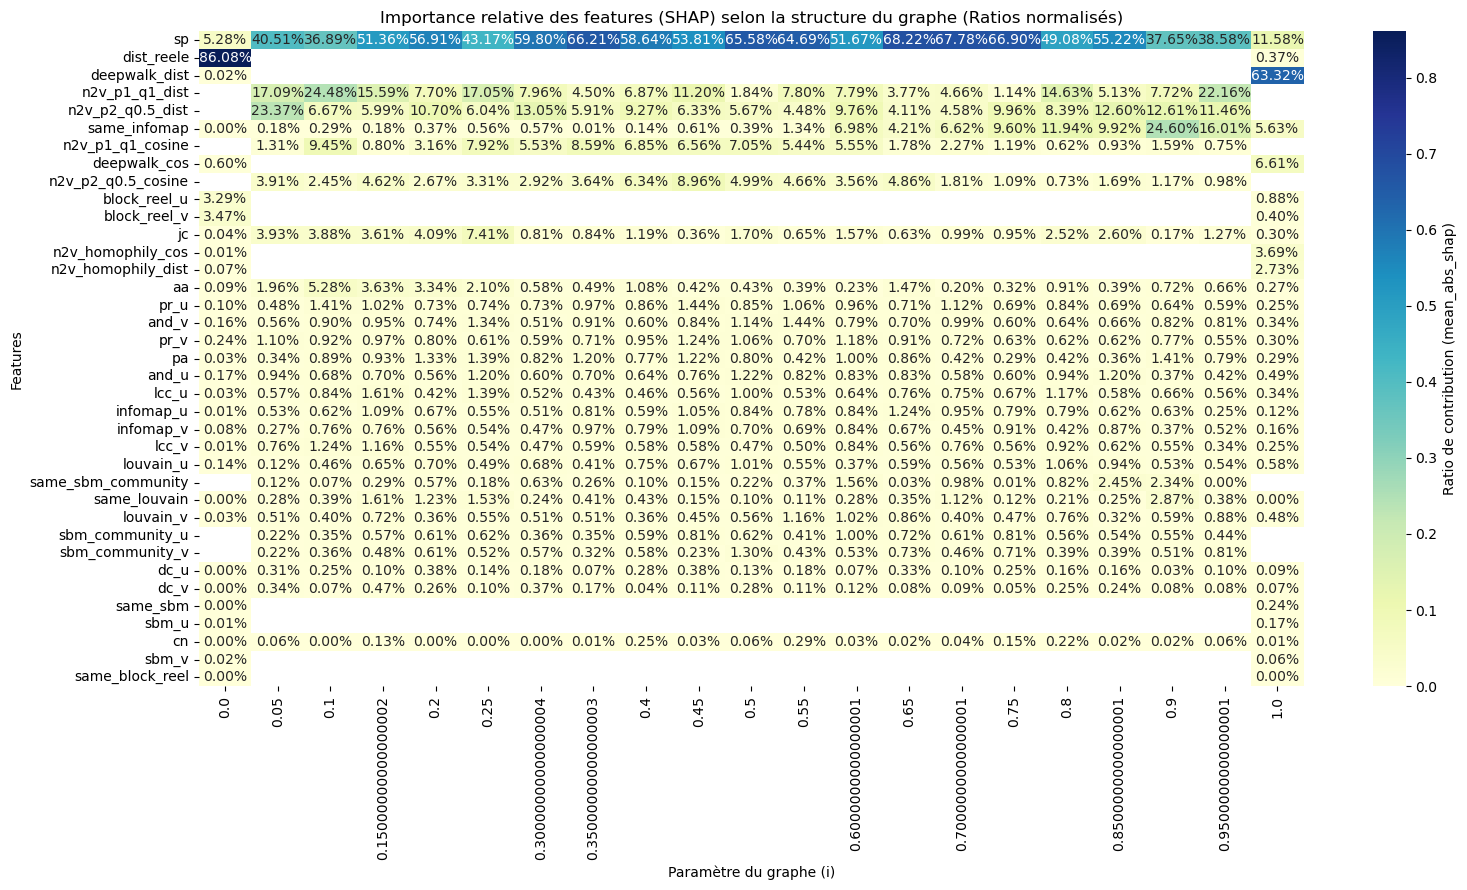

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_0_00_pos_1_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 38500 lignes, 33 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_abs_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, 
                annot=True,       
                fmt=fmt_type,        
                cmap="YlGnBu",    
                cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_final_results, as_ratio=True)


all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))

## 2 - Other

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


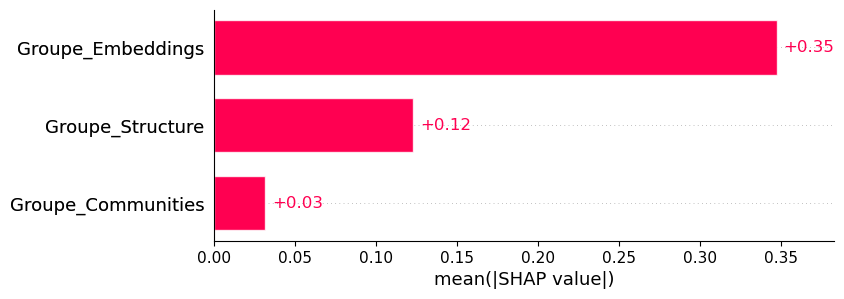


--- SHAP Bar Plot (Absolute) ---


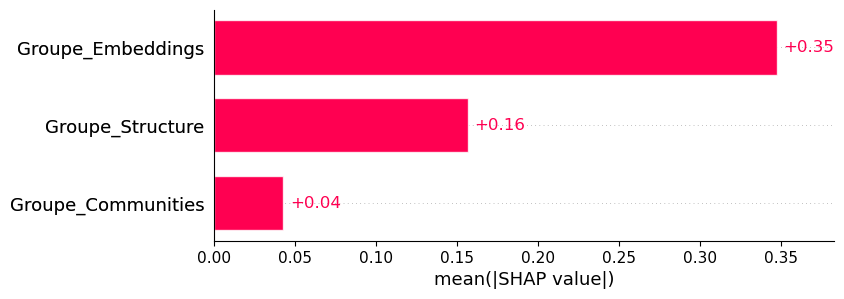


--- SHAP Custom Analysis ---


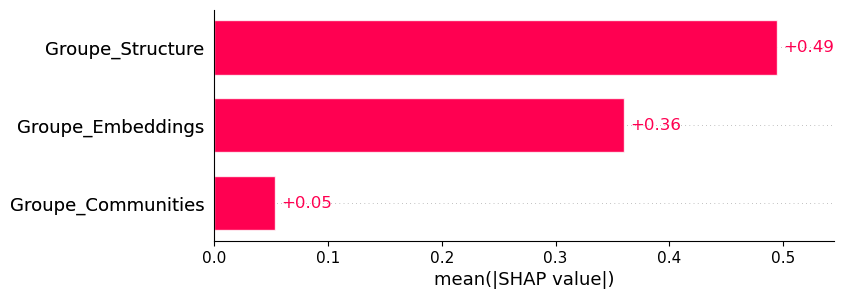


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


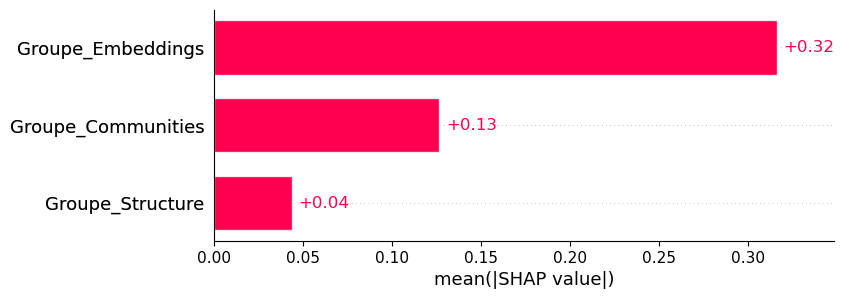


--- SHAP Bar Plot (Absolute) ---


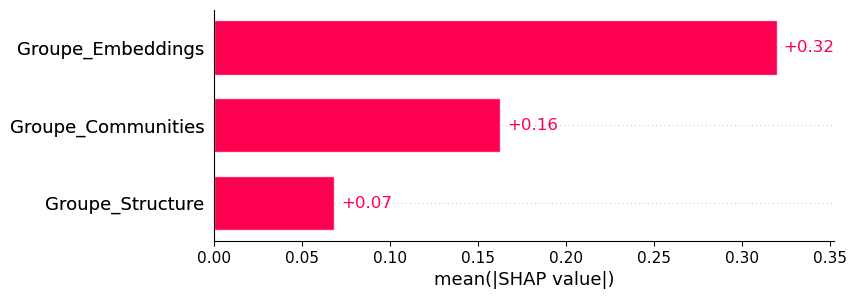


--- SHAP Custom Analysis ---


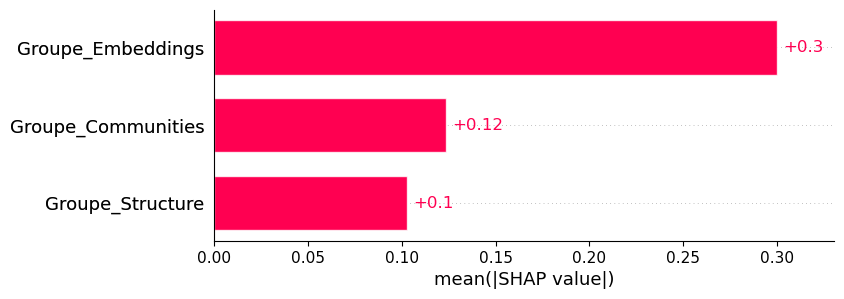


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
def xgboost_shap_pipeline(dataset, name):
    exclude = ['u', 'v', 'target', 'label']
    features = [col for col in dataset.columns if col not in exclude]
    
    results, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset, features=features)

    data_to_save = {
        "results": results,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "y_test": y_test,
        "y_train": y_train
    }

    print("Sauvegarde des données XGBoost (model,X1yTest et Train)")
    gp.loadsave_data_joblib(data=data_to_save,filename=f"xgboost_data_{name}.joblib", mode="save")

    print("\n RÉSULTATS")
    print(results.to_string(index=False))

    print("\n Shapley va ! Lu.")

    shap_explanation = gp.analyze_with_shap(model, X_test)
    print("Sauvegarde de l'analyse SHAP")
    gp.loadsave_data_joblib(data=shap_explanation, filename = f"shap_explainer_{name}.joblib", mode="save")

xgboost_shap_pipeline(dataset_sbm_1_true_groups, "TEST_W_REAL_GROUPS_SBM_1")
xgboost_shap_pipeline(dataset_sbm_0_5_true_groups, "TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


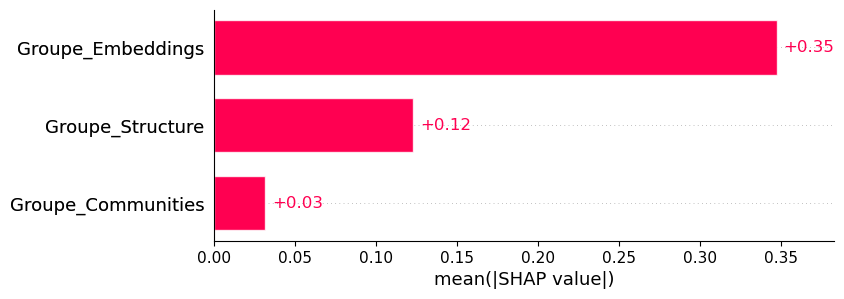


--- SHAP Bar Plot (Absolute) ---


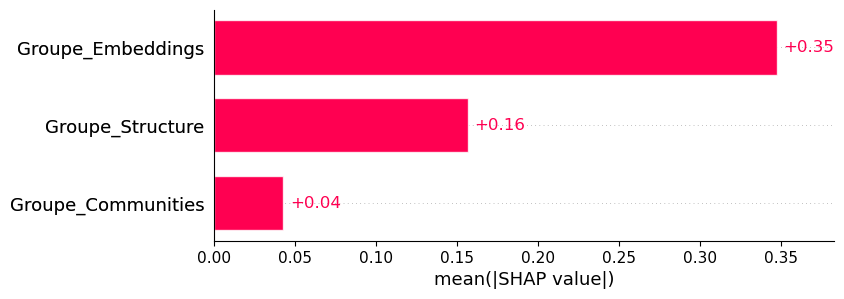


--- SHAP Custom Analysis ---


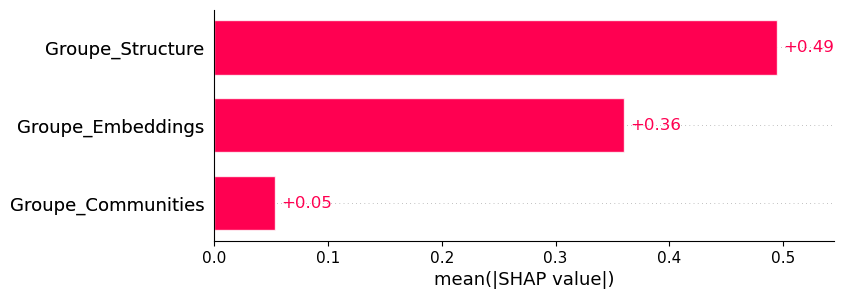


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


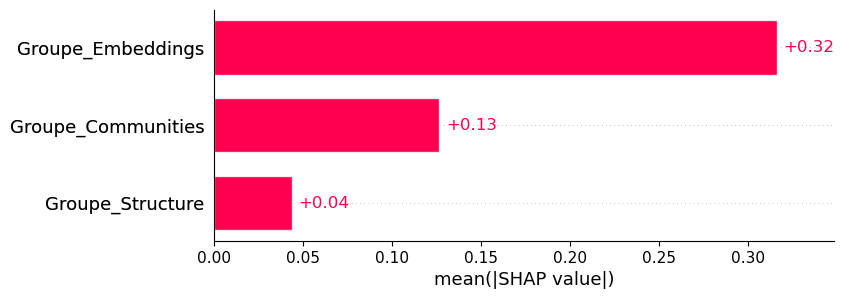


--- SHAP Bar Plot (Absolute) ---


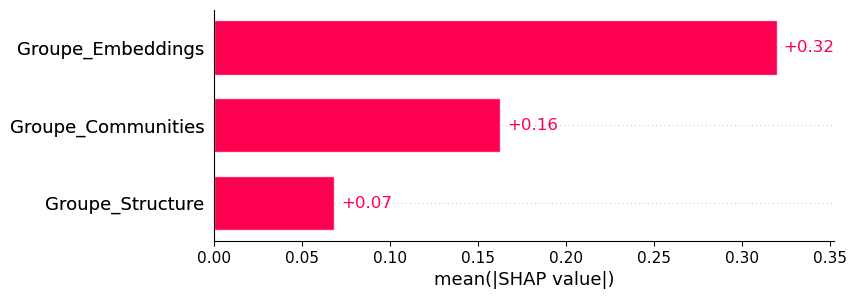


--- SHAP Custom Analysis ---


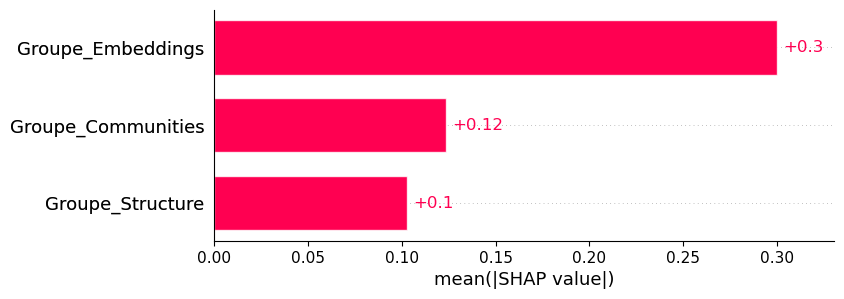


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
gp.evaluate("TEST_W_REAL_GROUPS_SBM_1", display = True)
gp.evaluate("TEST_W_REAL_GROUPS_SBM_0_5", display = True)

In [4]:
gp.display_shap("TEST_W_REAL_GROUPS_SBM_1")
gp.display_shap("TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib


1

In [30]:
dataset, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph("TEST_W_REAL_GROUPS_SBM_0_5")
dataset_base, xgboost_data_base, shap_explainer_base, shap_analysis_base = gp.load_all_data_for_graph("artificial_graph_sbm_0_50_pos_0_50")

gp.evaluate_model_performance(model = xgboost_data["model"], X_test = xgboost_data["X_test"], y_test = xgboost_data["y_test"], plot = False)
gp.evaluate_model_performance(model = xgboost_data_base["model"], X_test = xgboost_data_base["X_test"], y_test = xgboost_data_base["y_test"], plot = False)

print(dataset.head(2))
print(dataset_base.head(2))


dataset_cleared = dataset.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)
dataset_base_cleared = dataset_base.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)

print(dataset_cleared.head(2))
print(dataset_base_cleared.head(2))


all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_cleared)
all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_base)

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_TEST_W_REAL_GROUPS_SBM_0_5
 Taille : 6988 lignes, 23 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_50_pos_0_50
 Taille : 6988 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [43]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

all_results = []

for i in np.arange(0, 1.05, 0.05):
    
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    
    print(f"\n--- Évaluation : SBM {sbm_val} | POS {pos_val} ---")
    
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)

    print(dataset.columns)

    stats_df = gp.evaluate_model_performance(model=xgboost_data["model"], X_test=xgboost_data["X_test"], y_test=xgboost_data["y_test"], plot=False)
    
    all_results.append({
        "Graph_Name": G_name,
        "SBM_Ratio": i,
        "F1-Score": stats_df["F1-Score"].iloc[0]
    })

df_final_results = pd.DataFrame(all_results)

print("\n--- TABLEAU RÉCAPITULATIF ---")
print(df_final_results)

output_dir = os.path.join("outputs", "plots")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "artificial_graphs_recapitulatif_performances_f1.csv")

df_final_results.to_csv(output_path, index=False)

print(f"\n Tableau récapitulatif sauvegardé ici : {output_path}")


--- Évaluation : SBM 0.00 | POS 1.00 ---
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u',
       'community_v', 'same_community', 'infomap_u', 'infomap